# jaxmapse linear spectra and Halofit vs CLASS

This notebook compares:

1. Linear $P_{cb}(k,z)$ and $P_{mm}(k,z)$ from `jaxmapse` against CLASS.
2. Nonlinear $P_{mm}(k,z)$ from the low-effort `emu.get_halofit_pmm(...)` API against CLASS native Halofit.

The main jaxmapse nonlinear curve is self-contained on the jaxmapse side: it uses the emulated linear $P_{mm}$, native `jaxmapse.halofit_background`, and `jaxmapse.halofit_pmm` through the convenience method. A second diagnostic curve evaluates the same JAX Halofit kernel using CLASS background arrays, which helps separate background-convention differences from emulator/Halofit-kernel differences.

Vector-redshift spectra follow the jaxmapse convention: shape `(z, k)`.


In [1]:
from pathlib import Path
import sys

# Force this notebook to import the local checkout, not an installed jaxmapse.
def find_repo_root(start=None):
    p = Path.cwd().resolve() if start is None else Path(start).resolve()
    for q in [p, *p.parents]:
        if (q / "jaxmapse" / "__init__.py").exists() and (q / "Artifacts.toml").exists():
            return q
    raise RuntimeError("Could not find the local jaxmapse repository root.")

REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT))
for name in list(sys.modules):
    if name == "jaxmapse" or name.startswith("jaxmapse."):
        del sys.modules[name]

import jax
import jax.numpy as jnp
import jaxmapse
import matplotlib.pyplot as plt
import numpy as np
from classy import Class
from contextlib import contextmanager
import os

jax.config.update("jax_enable_x64", True)

print("repo root:", REPO_ROOT)
print("jaxmapse:", jaxmapse.__file__)
print("jax:", jax.__version__)
print("devices:", jax.devices())


repo root: /home/marcobonici/Desktop/work/CosmologicalEmulators/jaxmapse
jaxmapse: /home/marcobonici/Desktop/work/CosmologicalEmulators/jaxmapse/jaxmapse/__init__.py
jax: 0.4.38
devices: [CpuDevice(id=0)]


In [2]:
MODEL_NAME = "mnuw0wacdm_class"

emu = jaxmapse.trained_emulators.get(MODEL_NAME)
if emu is None:
    emu = jaxmapse.load_pk_emulator_from_artifact(MODEL_NAME)

k = np.asarray(emu.linear_pmm.k_grid)
print("k grid:", k.shape, k.min(), k.max())

# Parameter order for jaxmapse/Mapse mnuw0wacdm:
# [ln10As, ns, H0, omega_b, omega_cdm, Mnu, w0, wa]
emu_params = np.array([3.044, 0.9665, 67.1734, 0.022773, 0.15, 0.06, -1.5, 0.42523])
z_eval = np.array([0.0, 0.5, 1.0, 2.0])

h = emu_params[2] / 100.0
jax_cosmo = jaxmapse.w0waCDMCosmology(
    ln10As=emu_params[0],
    ns=emu_params[1],
    h=h,
    omega_b=emu_params[3],
    omega_c=emu_params[4],
    m_nu=emu_params[5],
    w0=emu_params[6],
    wa=emu_params[7],
)
D_eval = np.asarray(jax_cosmo.D_z(jnp.asarray(z_eval)))
print("z:", z_eval)
print("D(z):", D_eval)


k grid: (300,) 4.9999999999999996e-06 100.0
z: [0.  0.5 1.  2. ]
D(z): [0.85706911 0.63236992 0.48558378 0.32720524]


In [3]:
def class_parameters(emu_params, z_max, k_max, nonlinear=True):
    ln10As, ns, H0, omega_b, omega_cdm, Mnu, w0, wa = map(float, emu_params)
    params = {
        "output": "mPk",
        "P_k_max_1/Mpc": float(k_max),
        "z_max_pk": float(z_max),
        "h": H0 / 100.0,
        "omega_b": omega_b,
        "omega_cdm": omega_cdm,
        "N_ur": 2.0328,
        "N_ncdm": 1,
        "m_ncdm": Mnu,
        "tau_reio": 0.0544,
        "A_s": float(np.exp(ln10As) * 1e-10),
        "n_s": ns,
        "w0_fld": w0,
        "wa_fld": wa,
        "Omega_Lambda": 0.0,
        "fluid_equation_of_state": "CLP",
        "use_ppf": "yes",
    }
    if nonlinear:
        params["non linear"] = "halofit"
    return params


QUIET_CLASS = True


@contextmanager
def suppress_c_output(enabled=True):
    # CLASS/Halofit debug messages can be emitted from C stdout/stderr, not
    # Python's sys.stdout. Temporarily redirect file descriptors 1 and 2.
    if not enabled:
        yield
        return

    sys.stdout.flush()
    sys.stderr.flush()
    old_stdout = os.dup(1)
    old_stderr = os.dup(2)
    try:
        with open(os.devnull, "w") as devnull:
            os.dup2(devnull.fileno(), 1)
            os.dup2(devnull.fileno(), 2)
            yield
    finally:
        os.dup2(old_stdout, 1)
        os.dup2(old_stderr, 2)
        os.close(old_stdout)
        os.close(old_stderr)


def quiet_call(fn, *args, **kwargs):
    with suppress_c_output(QUIET_CLASS):
        return fn(*args, **kwargs)


def make_class(emu_params, z_eval, k, nonlinear=True):
    cosmo = Class()
    cosmo.set(
        class_parameters(
            emu_params,
            z_max=max(float(np.max(z_eval)) + 0.5, 3.0),
            k_max=float(np.max(k) * 1.05),
            nonlinear=nonlinear,
        )
    )
    quiet_call(cosmo.compute)
    return cosmo


def class_power_grid(cosmo, z_eval, k, method_name):
    method = getattr(cosmo, method_name)
    return quiet_call(
        lambda: np.array(
            [[method(float(kk), float(zz)) for kk in k] for zz in z_eval],
            dtype=float,
        )
    )


def class_background_for_halofit(cosmo, z_eval):
    bg = cosmo.get_background()
    z_table = np.asarray(bg["z"])
    order = np.argsort(z_table)
    z_sorted = z_table[order]
    omega_m_sorted = np.asarray(bg["Omega_m(z)"])[order]

    rho_crit = np.asarray(bg["(.)rho_crit"])
    rho_de = np.zeros_like(rho_crit)
    if "(.)rho_fld" in bg:
        rho_de = rho_de + np.asarray(bg["(.)rho_fld"])
    if "(.)rho_lambda" in bg:
        rho_de = rho_de + np.asarray(bg["(.)rho_lambda"])
    omega_v_sorted = (rho_de / rho_crit)[order]

    omega_m_z = np.interp(z_eval, z_sorted, omega_m_sorted)
    omega_v_z = np.interp(z_eval, z_sorted, omega_v_sorted)
    return omega_m_z, omega_v_z


In [4]:
# jaxmapse linear emulators: shape is (len(z), len(k)).
Pmm_emu = np.asarray(emu.get_linear_pmm(jnp.asarray(emu_params), jnp.asarray(z_eval), jnp.asarray(D_eval)))
Pcb_emu = np.asarray(emu.get_linear_pkcb(jnp.asarray(emu_params), jnp.asarray(z_eval), jnp.asarray(D_eval)))

# CLASS with native Halofit enabled. We use it for the reference spectra and for
# one optional diagnostic background comparison.
class_cosmo = make_class(emu_params, z_eval, k, nonlinear=True)
Pmm_class_lin = class_power_grid(class_cosmo, z_eval, k, "pk_lin")
Pcb_class_lin = class_power_grid(class_cosmo, z_eval, k, "pk_cb_lin")
Pmm_class_nl = class_power_grid(class_cosmo, z_eval, k, "pk")
omega_m_class_z, omega_v_class_z = class_background_for_halofit(class_cosmo, z_eval)

# Main low-effort jaxmapse nonlinear prediction. This computes growth, linear
# Pmm, native jaxmapse Halofit background, and JAX Halofit internally.
k_halofit, Pmm_jax_halofit = emu.get_halofit_pmm(jnp.asarray(emu_params), jnp.asarray(z_eval))
k_halofit = np.asarray(k_halofit)
Pmm_jax_halofit = np.asarray(Pmm_jax_halofit)
assert np.allclose(k_halofit, k)

# Pull out the native background only for display/diagnostics.
halofit_cosmo = jaxmapse.halofit_cosmology(jnp.asarray(emu_params))
omega_m_jax_z, omega_v_jax_z = jaxmapse.halofit_background(halofit_cosmo, jnp.asarray(z_eval))
omega_m_jax_z = np.asarray(omega_m_jax_z)
omega_v_jax_z = np.asarray(omega_v_jax_z)

# Diagnostic only: same convenience method, but with CLASS background arrays.
# If this differs from the main curve, the difference is in the background
# convention, not the Halofit kernel.
_, Pmm_jax_halofit_class_bg = emu.get_halofit_pmm(
    jnp.asarray(emu_params),
    jnp.asarray(z_eval),
    D=jnp.asarray(D_eval),
    omega_m_z=jnp.asarray(omega_m_class_z),
    omega_v_z=jnp.asarray(omega_v_class_z),
)
Pmm_jax_halofit_class_bg = np.asarray(Pmm_jax_halofit_class_bg)

class_cosmo.struct_cleanup()
class_cosmo.empty()

print("Pmm_emu:", Pmm_emu.shape)
print("Pcb_emu:", Pcb_emu.shape)
print("Pmm_jax_halofit:", Pmm_jax_halofit.shape)
print("jaxmapse Ωm(z):", omega_m_jax_z)
print("jaxmapse Ωv(z):", omega_v_jax_z)
print("CLASS Ωm(z):", omega_m_class_z)
print("CLASS Ωv(z):", omega_v_class_z)
print("max |Ωm_jax - Ωm_CLASS|:", np.max(np.abs(omega_m_jax_z - omega_m_class_z)))
print("max |Ωv_jax - Ωv_CLASS|:", np.max(np.abs(omega_v_jax_z - omega_v_class_z)))


Pmm_emu: (4, 300)
Pcb_emu: (4, 300)
Pmm_jax_halofit: (4, 300)
jaxmapse Ωm(z): [0.38432377 0.77914224 0.9167114  0.98016454]
jaxmapse Ωv(z): [0.61562151 0.22069137 0.08302757 0.01941681]
CLASS Ωm(z): [0.38432386 0.77908861 0.91660218 0.97997163]
CLASS Ωv(z): [0.61559589 0.22066714 0.08301433 0.01941225]
max |Ωm_jax - Ωm_CLASS|: 0.00019290860784137998
max |Ωv_jax - Ωv_CLASS|: 2.5624918058242407e-05


In [5]:
def relerr(model, reference):
    return model / reference - 1.0


def percent_relerr(model, reference):
    return 100.0 * relerr(model, reference)

# Avoid treating the extreme outside-use grid tail as the only number that matters.
summary_mask = (k >= 1e-4) & (k <= 10.0)

comparisons = {
    "linear Pmm emulator vs CLASS": percent_relerr(Pmm_emu, Pmm_class_lin),
    "linear Pcb emulator vs CLASS": percent_relerr(Pcb_emu, Pcb_class_lin),
    "Halofit(emulated Pmm, jaxmapse bg) vs CLASS nonlinear Pmm": percent_relerr(Pmm_jax_halofit, Pmm_class_nl),
    "diagnostic: Halofit(emulated Pmm, CLASS bg) vs CLASS nonlinear Pmm": percent_relerr(Pmm_jax_halofit_class_bg, Pmm_class_nl),
}

for name, err_pct in comparisons.items():
    e = err_pct[:, summary_mask]
    print(f"{name}")
    print(f"  mean |rel| = {np.mean(np.abs(e)):.4e}%")
    print(f"  rms  rel   = {np.sqrt(np.mean(e**2)):.4e}%")
    print(f"  max  |rel| = {np.max(np.abs(e)):.4e}%")


linear Pmm emulator vs CLASS
  mean |rel| = 2.7845e-02%
  rms  rel   = 4.8678e-02%
  max  |rel| = 2.5205e-01%
linear Pcb emulator vs CLASS
  mean |rel| = 3.7806e-02%
  rms  rel   = 4.6110e-02%
  max  |rel| = 1.2584e-01%
Halofit(emulated Pmm, jaxmapse bg) vs CLASS nonlinear Pmm
  mean |rel| = 2.7600e-02%
  rms  rel   = 4.8456e-02%
  max  |rel| = 2.5204e-01%
diagnostic: Halofit(emulated Pmm, CLASS bg) vs CLASS nonlinear Pmm
  mean |rel| = 2.8028e-02%
  rms  rel   = 4.8556e-02%
  max  |rel| = 2.5204e-01%


## JAX-only convenience function and benchmark

The cell below defines the user-facing JAX-only nonlinear pipeline as a single jitted function. It closes over the loaded emulator and calls the low-effort API:

```python
k, pk_nl = emu.get_halofit_pmm(params, z)
```

Internally this computes growth, linear emulator `Pmm`, native jaxmapse Halofit background, and JAX Halofit. The benchmark blocks on the result so `%timeit` measures execution rather than asynchronous dispatch.


In [6]:
params_jax = jnp.asarray(emu_params)
z_eval_jax = jnp.asarray(z_eval)
z_bench_jax = jnp.linspace(0.0, 2.0, 100)


@jax.jit
def jax_only_halofit_pmm(params, z):
    return emu.get_halofit_pmm(params, z)


# Compile and sanity-check the function before benchmarking.
k_jit, pk_nl_jit = jax_only_halofit_pmm(params_jax, z_eval_jax)
jax.block_until_ready((k_jit, pk_nl_jit))
assert pk_nl_jit.shape == Pmm_jax_halofit.shape
assert np.allclose(np.asarray(k_jit), k)
assert np.allclose(np.asarray(pk_nl_jit), Pmm_jax_halofit)

# Compile the 100-redshift benchmark shape separately. JAX specializes on shape.
k_bench, pk_nl_bench = jax_only_halofit_pmm(params_jax, z_bench_jax)
jax.block_until_ready((k_bench, pk_nl_bench))
print("z_eval shape:", z_eval_jax.shape, "pk shape:", pk_nl_jit.shape)
print("z_bench shape:", z_bench_jax.shape, "pk shape:", pk_nl_bench.shape)


z_eval shape: (4,) pk shape: (4, 300)
z_bench shape: (100,) pk shape: (100, 300)


In [7]:
# Small notebook comparison shape.
%timeit -n 100 -r 50 jax.block_until_ready(jax_only_halofit_pmm(params_jax, z_eval_jax))

# More realistic many-redshift shape.
%timeit -n 100 -r 50 jax.block_until_ready(jax_only_halofit_pmm(params_jax, z_bench_jax))

922 μs ± 141 μs per loop (mean ± std. dev. of 50 runs, 100 loops each)
4.61 ms ± 257 μs per loop (mean ± std. dev. of 50 runs, 100 loops each)


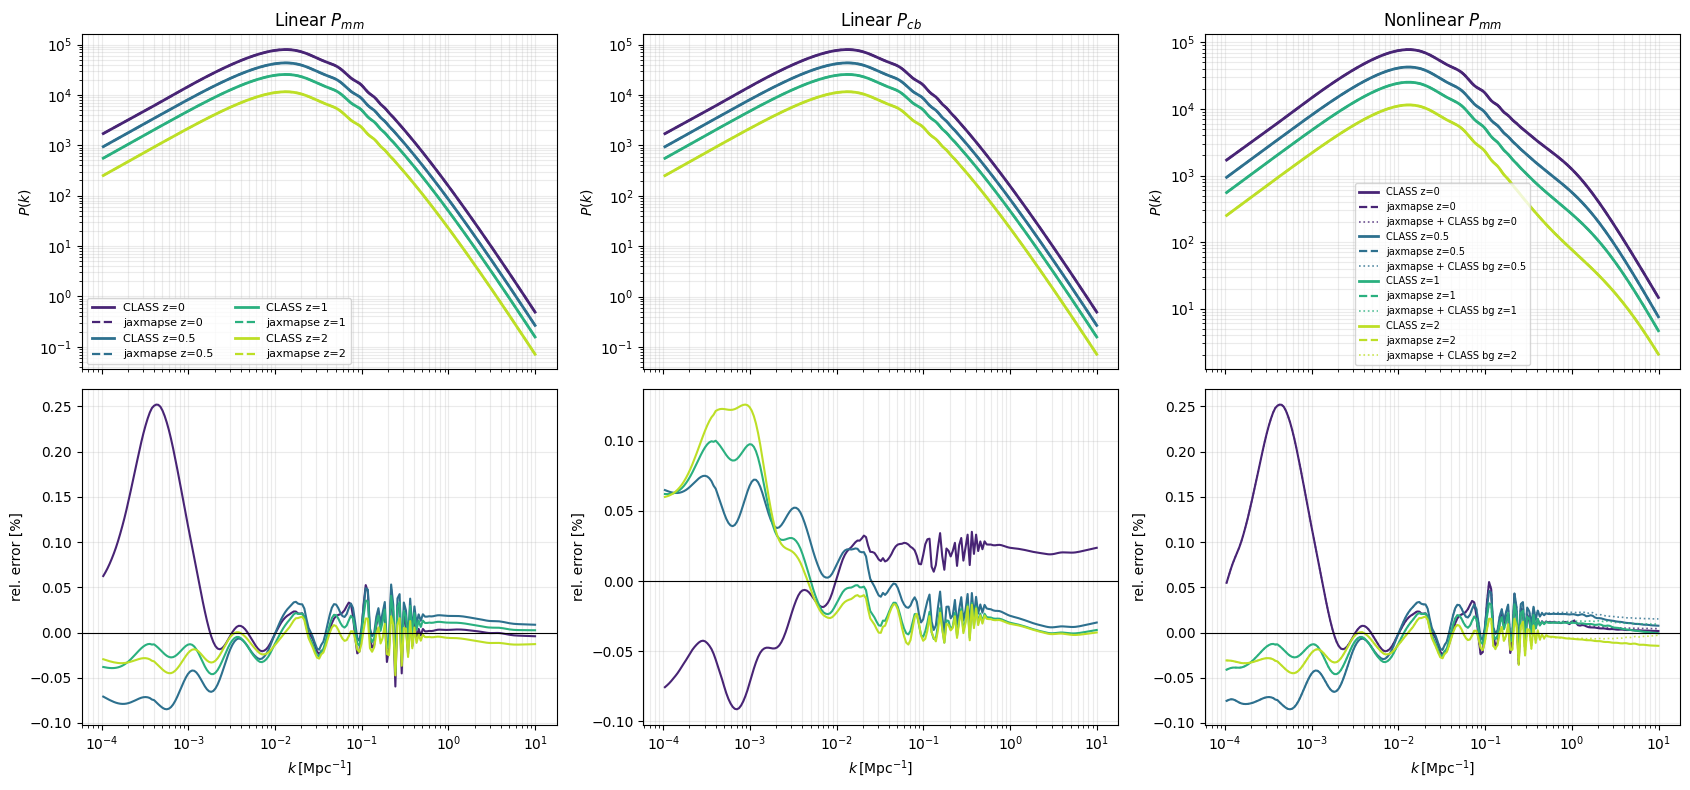

In [8]:
plot_mask = (k >= 1e-4) & (k <= 10.0)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(z_eval)))

fig, axes = plt.subplots(2, 3, figsize=(17, 8), sharex="col")
items = [
    ("Linear $P_{mm}$", Pmm_emu, Pmm_class_lin),
    ("Linear $P_{cb}$", Pcb_emu, Pcb_class_lin),
    ("Nonlinear $P_{mm}$", Pmm_jax_halofit, Pmm_class_nl),
]

for col, (title, model, reference) in enumerate(items):
    ax = axes[0, col]
    rax = axes[1, col]
    for iz, (zz, color) in enumerate(zip(z_eval, colors)):
        ax.loglog(k[plot_mask], reference[iz, plot_mask], color=color, lw=2, label=f"CLASS z={zz:g}")
        ax.loglog(k[plot_mask], model[iz, plot_mask], color=color, ls="--", lw=1.6, label=f"jaxmapse z={zz:g}")
        if col == 2:
            ax.loglog(
                k[plot_mask],
                Pmm_jax_halofit_class_bg[iz, plot_mask],
                color=color,
                ls=":",
                lw=1.2,
                alpha=0.8,
                label=f"jaxmapse + CLASS bg z={zz:g}",
            )
        rax.semilogx(k[plot_mask], percent_relerr(model, reference)[iz, plot_mask], color=color, lw=1.5)
        if col == 2:
            rax.semilogx(
                k[plot_mask],
                percent_relerr(Pmm_jax_halofit_class_bg, reference)[iz, plot_mask],
                color=color,
                ls=":",
                lw=1.2,
                alpha=0.8,
            )
    ax.set_title(title)
    ax.set_ylabel(r"$P(k)$")
    ax.grid(True, which="both", alpha=0.25)
    rax.axhline(0.0, color="k", lw=0.8)
    rax.set_xlabel(r"$k\,[{\rm Mpc}^{-1}]$")
    rax.set_ylabel("rel. error [%]")
    rax.grid(True, which="both", alpha=0.25)

axes[0, 0].legend(fontsize=8, ncol=2)
axes[0, 2].legend(fontsize=7, ncol=1)
fig.tight_layout()
plt.show()


## Notes

- The linear emulator outputs are compared against CLASS linear `pk_lin` and `pk_cb_lin` on the emulator k-grid.
- The main nonlinear jaxmapse curve is **not** the artifact `Boost` component. It is `emu.get_halofit_pmm(params, z)`, which internally computes growth, emulated linear $P_{mm}$, native `jaxmapse.halofit_background(...)`, and `jaxmapse.halofit_pmm(...)`.
- The dotted nonlinear curve is diagnostic only: same convenience method and same emulated linear $P_{mm}$, but with CLASS background arrays. It helps identify whether any nonlinear discrepancy is due to background conventions.
- jaxmapse returns vector-redshift spectra as `(z, k)`. Mapse.jl uses `(k, z)`.
